In [7]:
import sys
from pathlib import Path
import pickle

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

sys.path.append(str(Path.cwd().parent))

from resplan_utils import *

from shapely import affinity
from shapely.ops import unary_union
from shapely.geometry.base import BaseGeometry


CLASS_ORDER = [
    "living",
    "bedroom",
    "bathroom",
    "kitchen",
    "door",
    "window",
    "wall",
    "front_door",
    "balcony",
]


def fit_plan_to_canvas(plan, shape=(256, 256), padding=8):
    h, w = shape

    geoms = [
        g for g in plan.values()
        if isinstance(g, BaseGeometry) and not g.is_empty
    ]

    bounds_geom = unary_union(geoms)
    minx, miny, maxx, maxy = bounds_geom.bounds

    plan_w = maxx - minx
    plan_h = maxy - miny

    scale = min(
        (w - 2 * padding) / plan_w,
        (h - 2 * padding) / plan_h,
    )

    fitted = {}

    for key, value in plan.items():
        if isinstance(value, BaseGeometry):
            g = affinity.translate(value, xoff=-minx, yoff=-miny)
            g = affinity.scale(g, xfact=scale, yfact=scale, origin=(0, 0))
            g = affinity.translate(g, xoff=padding, yoff=padding)
            fitted[key] = g
        else:
            fitted[key] = value

    return fitted


class ResPlanSegmentationDataset(Dataset):
    def __init__(
        self,
        pkl_path,
        shape=(256, 256),
        classes=None,
        normalize_image=True,
        augment=None,
        padding=8,
    ):
        self.pkl_path = pkl_path
        self.shape = shape
        self.normalize_image = normalize_image
        self.augment = augment
        self.padding = padding

        with open(pkl_path, "rb") as f:
            self.plans = pickle.load(f)

        for plan in self.plans:
            normalize_keys(plan)

        if classes is None:
            found_classes = self._get_classes_from_all_plans()
            self.classes = [c for c in CLASS_ORDER if c in found_classes]
        else:
            self.classes = classes

        self.class_to_idx = {
            class_name: idx + 1
            for idx, class_name in enumerate(self.classes)
        }

        self.idx_to_class = {
            idx: class_name
            for class_name, idx in self.class_to_idx.items()
        }

        self.num_classes = len(self.classes) + 1

    def _get_classes_from_all_plans(self):
        found_classes = set()

        for plan in self.plans:
            normalize_keys(plan)

            for key in CLASS_ORDER:
                if key in plan and plan[key] is not None:
                    found_classes.add(key)

        return found_classes

    def __len__(self):
        return len(self.plans)

    def _make_image(self, plan):
        img = get_2d_plan(
            plan,
            shape=self.shape,
            show=False,
            diff=True,
        )

        # add balcony into input image
        balcony = plan.get("balcony")
        if balcony is not None:
            balcony_mask = geometry_to_mask(
                balcony,
                shape=self.shape,
                line_thickness=0,
            )

            balcony_mask = np.flipud(balcony_mask).copy()
            img[balcony_mask > 0] = 200   # light gray balcony

        img = img.copy()

        if self.normalize_image:
            img = img.astype(np.float32) / 255.0
        else:
            img = img.astype(np.float32)

        img = np.expand_dims(img, axis=0)

        return img

    def _make_mask(self, plan):
        mask = np.zeros(self.shape, dtype=np.uint8)

        for class_name in self.classes:
            geom = plan.get(class_name)

            if geom is None:
                continue

            binary_mask = geometry_to_mask(
                geom,
                shape=self.shape,
                line_thickness=0,
            )

            label_id = self.class_to_idx[class_name]
            mask[binary_mask > 0] = label_id

        mask = np.flipud(mask).copy()

        return mask

    def __getitem__(self, idx):
        plan = fit_plan_to_canvas(
            self.plans[idx],
            shape=self.shape,
            padding=self.padding,
        )

        image = self._make_image(plan)
        mask = self._make_mask(plan)

        if self.augment is not None:
            augmented = self.augment(
                image=image.transpose(1, 2, 0),
                mask=mask,
            )

            image = augmented["image"].transpose(2, 0, 1).copy()
            mask = augmented["mask"].copy()

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


PKL_PATH = "../ResPlan.pkl"

dataset = ResPlanSegmentationDataset(
    pkl_path=PKL_PATH,
    shape=(256, 256),
    padding=8,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Num classes:", dataset.num_classes)

images, masks = next(iter(loader))

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Mask labels:", torch.unique(masks))

Classes: ['living', 'bedroom', 'bathroom', 'kitchen', 'door', 'window', 'wall', 'front_door', 'balcony']
Class mapping: {'living': 1, 'bedroom': 2, 'bathroom': 3, 'kitchen': 4, 'door': 5, 'window': 6, 'wall': 7, 'front_door': 8, 'balcony': 9}
Num classes: 10
Images: torch.Size([8, 1, 256, 256])
Masks: torch.Size([8, 256, 256])
Mask labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


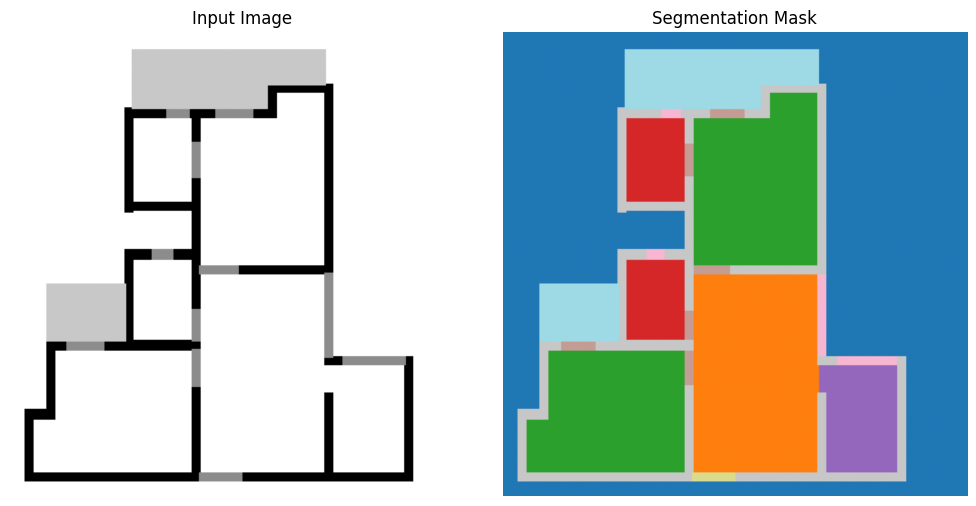

Unique labels in mask: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Class mapping: {'living': 1, 'bedroom': 2, 'bathroom': 3, 'kitchen': 4, 'door': 5, 'window': 6, 'wall': 7, 'front_door': 8, 'balcony': 9}


<Axes: >

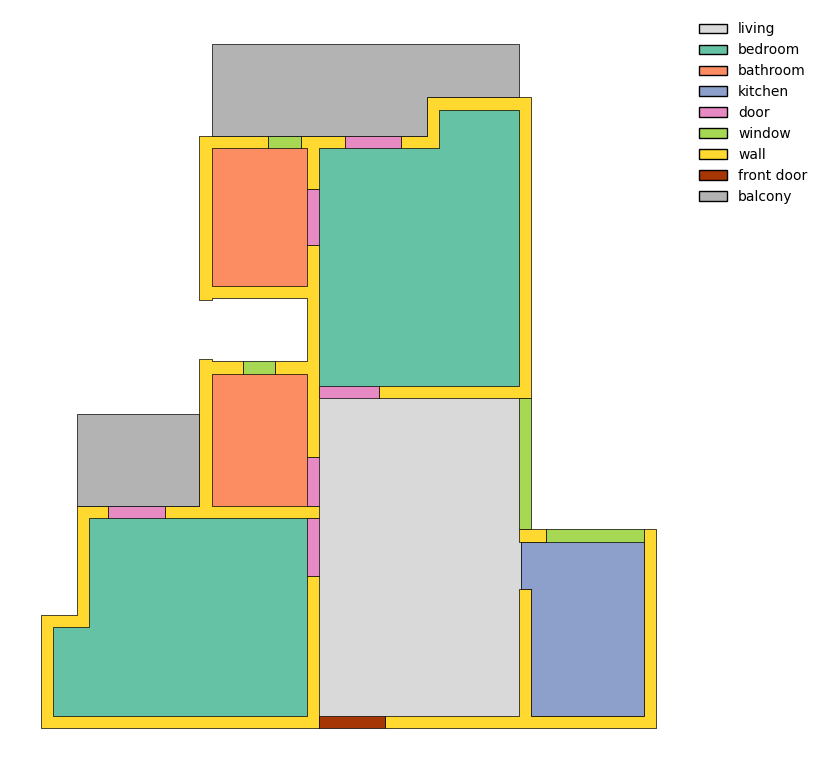

In [8]:
import matplotlib.pyplot as plt
import torch

images, masks = next(iter(loader))

idx = 2

image = images[idx].squeeze().cpu().numpy()
mask = masks[idx].cpu().numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab20", vmin=0, vmax=loader.dataset.num_classes - 1)
plt.title("Segmentation Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Unique labels in mask:", torch.unique(masks[idx]))
print("Class mapping:", loader.dataset.class_to_idx)

DATA_PATH = '../ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

plot_plan(plans[idx])
